# Cohort DNA: recurrent mutations and their interactions (MHN + TreeMHN)

Across a cohort of patients that share a **mutational landscape**, two questions define cancer
progression modelling: **which** events recur, and **in what combinations / order** they arise.
**MHN** (Mutual Hazard Networks) learns pairwise co-occurrence / exclusivity from cross-sectional
presence; **TreeMHN** adds **order** from per-patient mutation trees.

iscc plants a **known** epistasis network — shared by every patient of the cohort (drawn from the
`layout_seed` stream) — so these tools have a ground truth to be scored against. We grow five patients
over that one shared network (`base_sim`'s shared landscape + an added epistasis network), and recover
the recurrence spectrum, the interactions, and the order.

> An important, honest caveat this notebook surfaces: iscc's pairwise interactions act on **fitness**
> (clone *size*), while MHN's binary presence observable is nearly blind to that — recovery depends on
> the **detection threshold**, not the cohort size. The full analysis is
> `validation/validate_epistasis.py`. The real tools run in their own envs (`iscc-mhn`,
> `iscc-treemhn`) when present, with in-core fallbacks so the notebook always executes.

In [1]:
%matplotlib inline
import os, sys, subprocess, tempfile
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import base_sim as B
from iscc import integrations as ig

HOME = os.path.expanduser("~")
VALID = os.path.abspath(os.path.join(os.path.dirname(B.__file__), "..", "validation"))
MHN_PY = os.path.join(HOME, "miniconda3/envs/iscc-mhn/bin/python")
MHN_RUNNER = os.path.join(VALID, "mhn_runner.py")
TREEMHN_RS = os.path.join(HOME, "miniconda3/envs/iscc-treemhn/bin/Rscript")
TREEMHN_RUNNER = os.path.join(VALID, "treemhn_runner.R")

def run_mhn(X, lam="cv"):
    if not os.path.exists(MHN_PY):
        return None
    try:
        with tempfile.TemporaryDirectory() as d:
            fin, fout = os.path.join(d, "in.csv"), os.path.join(d, "out.csv")
            X.to_csv(fin)
            r = subprocess.run([MHN_PY, MHN_RUNNER, fin, fout, str(lam)],
                               capture_output=True, text=True, timeout=600)
            return pd.read_csv(fout, index_col=0) if (r.returncode == 0 and os.path.exists(fout)) else None
    except Exception:
        return None

def run_treemhn(trees, gamma=0.5):
    if not os.path.exists(TREEMHN_RS):
        return None
    try:
        with tempfile.TemporaryDirectory() as d:
            fin, fout = os.path.join(d, "trees.csv"), os.path.join(d, "out.csv")
            trees.to_csv(fin, index=False)
            r = subprocess.run([TREEMHN_RS, TREEMHN_RUNNER, fin, fout, str(gamma)],
                               capture_output=True, text=True, timeout=900)
            return pd.read_csv(fout, index_col=0) if (r.returncode == 0 and os.path.exists(fout)) else None
    except Exception:
        return None

## 1. Grow the cohort over one shared epistasis network

We add an epistasis network to the shared selection landscape (a couple of pairwise interactions plus
an accessibility-gated ordering constraint) and grow the five patients **one at a time**, extracting
each patient's compact summaries (event cancer-cell fractions, mutation tree, event orders) and
releasing the tumour before the next — so we never hold five in memory. The network is planted once and
shared; we verify the planted interaction matrix is identical across patients.

In [2]:
EPI = {"n_events": 5, "event_size": 3, "n_interactions": 2, "interaction_strength": 1.6,
       "interaction_strength_sd": 0.0, "prop_synergy": 1.0, "event_effect_mean": 0.0,
       "event_effect_sd": 0.0}
DEP = {"n_constraints": 1, "dag_depth": 2, "dag_branching": 1, "gating_mode": "accessibility"}
SEL = {"epistasis_params": EPI, "dependency_params": DEP}

F_rows, tree_frames, order_groups, event_sets = [], [], [], []
E_true = event_names = dag = n_events = spatial = None
identical = True
for s, tum in B.grow_cohort(selection_params=SEL):
    net_i = tum.selection.epistasis
    if E_true is None:
        E_true = net_i.true_interaction_matrix(); event_names = list(net_i.event_names())
        dag = net_i.true_dag_edges(); n_events = net_i.n_events
        ty = B.cell_types(tum); crd = tum.cell_data["cell_crd"]
        spatial = dict(row=crd["row"].values.copy(), col=crd["col"].values.copy(),
                       types=ty.copy(), gland=B.cell_gland(tum).copy(),
                       n_glands=len(B.glands_colonised(tum)), seed=s)
    identical &= np.allclose(E_true, net_i.true_interaction_matrix())
    F_rows.append(np.asarray(ig.event_cell_fractions(tum, n_events=n_events)))
    df = ig.to_mutation_tree(tum)
    if len(df) >= 2:
        tree_frames.append(df)
    ce = ig.clone_events(tum)
    order_groups.extend([tuple(g) for g in ce["event_groups"]])
    event_sets.extend([tuple(int(e) for e in ev) for ev in ce["events"]])
    print(f"  patient P{s}: {tum.get_cancer_size():,} cancer cells", flush=True)
    del tum

F = pd.DataFrame(F_rows, columns=event_names, index=[f"P{i}" for i in range(len(F_rows))])
trees = pd.concat([df.assign(Patient_ID=i + 1, Tree_ID=i + 1)[
                       ["Patient_ID", "Tree_ID", "Node_ID", "Mutation_ID", "Parent_ID", "n_cells"]]
                   for i, df in enumerate(tree_frames)], ignore_index=True)
print(f"\nplanted interaction network identical across all patients: {identical}")
print("events:", event_names)

  patient P3: 12,057 cancer cells


  patient P4: 11,853 cancer cells


  patient P5: 11,446 cancer cells


  patient P6: 12,217 cancer cells


  patient P7: 10,613 cancer cells



planted interaction network identical across all patients: True
events: ['E0', 'E1', 'E2', 'E3', 'E4']


Each patient is the same multi-focal DCIS→IDC ductal field as the rest of the suite (malignant foci in
a normal microenvironment); here is the first patient's structure — by true cell type, and by
`cell_gland` (which gland each malignant cell colonised, stroma-invaded cancer in black).

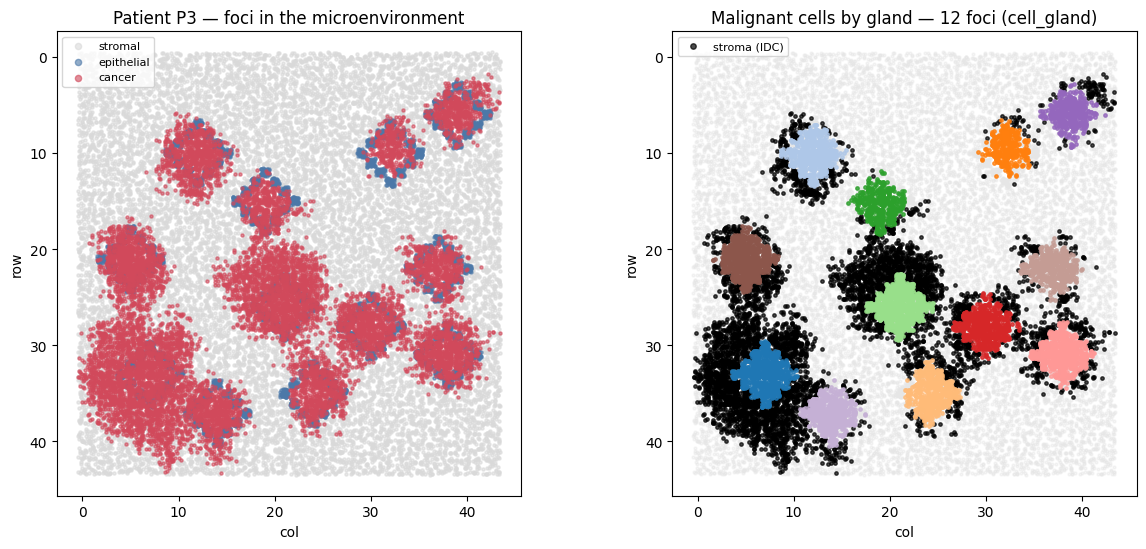

In [3]:
jit = np.random.default_rng(1)
jx = spatial["col"] + jit.uniform(-0.45, 0.45, len(spatial["col"]))
jy = spatial["row"] + jit.uniform(-0.45, 0.45, len(spatial["row"]))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6))
for name, col in {"stromal": "0.85", "epithelial": "#4c78a8", "cancer": "#d1495b"}.items():
    m = spatial["types"] == name
    axes[0].scatter(jx[m], jy[m], s=5, c=col, alpha=0.6, label=name)
axes[0].set_aspect("equal"); axes[0].invert_yaxis(); axes[0].legend(fontsize=8, markerscale=2)
axes[0].set_title(f"Patient P{spatial['seed']} — foci in the microenvironment")
axes[0].set_xlabel("col"); axes[0].set_ylabel("row")

cmap = plt.get_cmap("tab20")
mc = spatial["types"] == "cancer"; gvals = spatial["gland"][mc]
axes[1].scatter(jx[~mc], jy[~mc], s=4, c="0.9", alpha=0.4)
axes[1].scatter(jx[mc][gvals == -1], jy[mc][gvals == -1], s=6, c="k", alpha=0.7, label="stroma (IDC)")
for g in sorted(set(gvals[gvals >= 0])):
    m = gvals == g
    axes[1].scatter(jx[mc][m], jy[mc][m], s=6, color=cmap(int(g) % 20), alpha=0.8)
axes[1].set_aspect("equal"); axes[1].invert_yaxis(); axes[1].legend(fontsize=8, markerscale=1.6)
axes[1].set_title(f"Malignant cells by gland — {spatial['n_glands']} foci (cell_gland)")
axes[1].set_xlabel("col"); axes[1].set_ylabel("row")
plt.tight_layout()

## 2. The recurrence spectrum

Every patient shares the landscape, so the same events recur — but *how much* of each tumour a shared
event occupies varies (that clone **fraction** is what selection acts on). The continuous cancer-cell-
fraction matrix shows this. To hand MHN a **binary** presence matrix with actual variance to learn
from, we pick the detection threshold that maximises across-patient variance — because at a low
threshold every event is present in every patient (saturated), the very effect the epistasis benchmark
warns about.

data-driven detection threshold = 0.51
presence matrix (patients x events):
    E0  E1  E2  E3  E4
P0   1   0   1   0   1
P1   0   0   1   0   0
P2   1   0   0   1   1
P3   1   0   1   0   0
P4   1   0   0   1   0


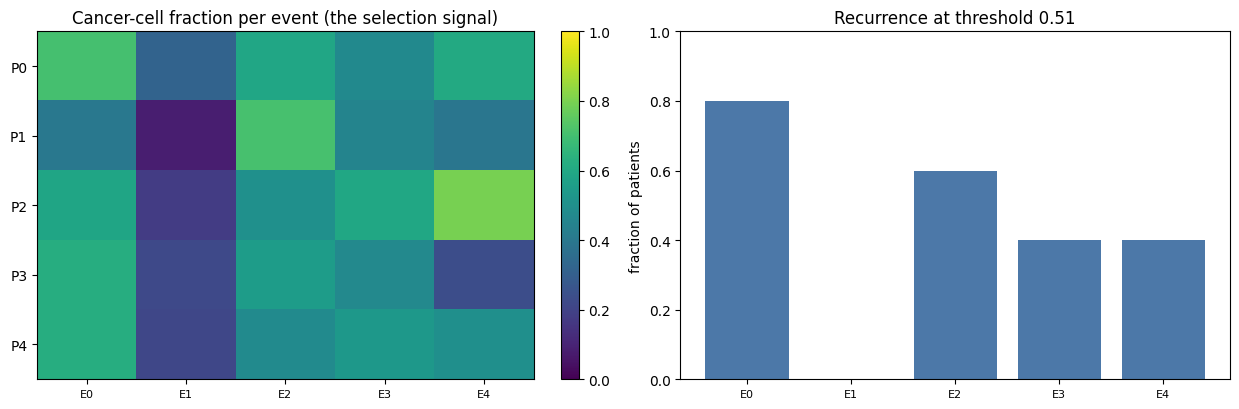

In [4]:
grid = np.linspace(0.05, 0.95, 40)
THR = float(max(grid, key=lambda x: (F.values >= x).astype(int).var(0).sum()))
X = pd.DataFrame((F.values >= THR).astype(int), index=F.index, columns=list(F.columns))
print(f"data-driven detection threshold = {THR:.2f}")
print("presence matrix (patients x events):"); print(X.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
im = axes[0].imshow(F.values, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axes[0].set_xticks(range(len(event_names))); axes[0].set_xticklabels(event_names, fontsize=8)
axes[0].set_yticks(range(len(F))); axes[0].set_yticklabels(list(F.index))
axes[0].set_title("Cancer-cell fraction per event (the selection signal)")
plt.colorbar(im, ax=axes[0], fraction=0.046)
axes[1].bar(range(len(event_names)), (F.values >= THR).mean(0), color="#4c78a8")
axes[1].set_xticks(range(len(event_names))); axes[1].set_xticklabels(event_names, fontsize=8)
axes[1].set_ylabel("fraction of patients"); axes[1].set_ylim(0, 1)
axes[1].set_title(f"Recurrence at threshold {THR:.2f}")
plt.tight_layout()

## 3. MHN: the interaction network

We fit **MHN** (real tool in `iscc-mhn` when present, else the DISCOVER-style co-occurrence floor) and
compare its inferred interaction matrix to the planted answer key `E`. Fitness epistasis is hard to
read off binary presence (see the caveat), so we report the recovery honestly alongside the floor.

planted interacting pairs: [(0, 3), (1, 3)]
top inferred pairs:        [(0, 1), (2, 3)]
overlap: 0/2


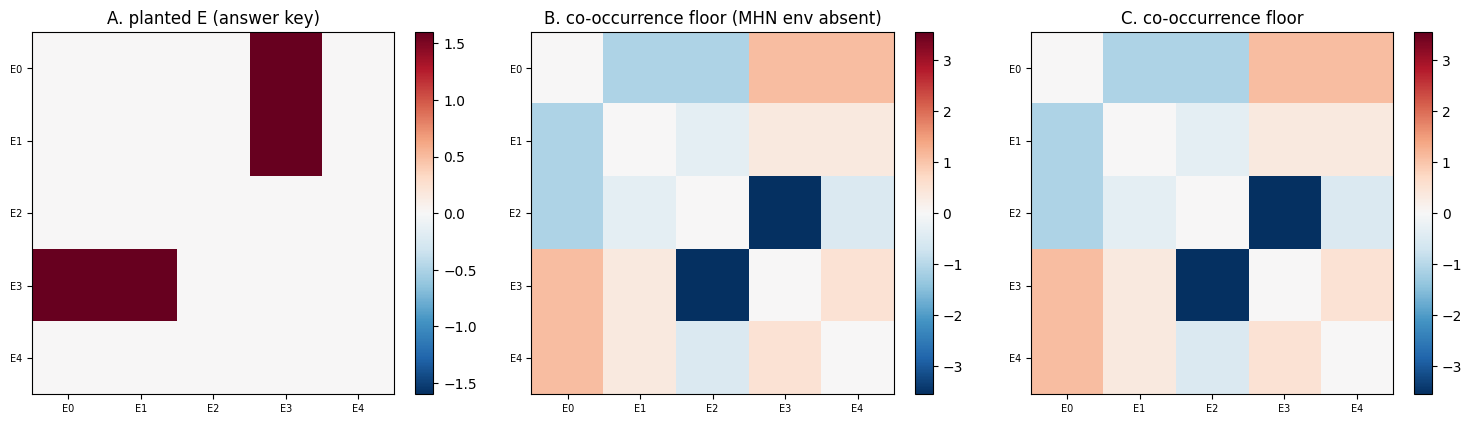

In [5]:
theta = run_mhn(X)
floor = ig.cooccurrence_scores(X.values)
if theta is not None:
    M = theta.values.copy(); np.fill_diagonal(M, 0.0); mhn_label = "MHN (iscc-mhn)"
else:
    M = floor.copy(); np.fill_diagonal(M, 0.0); mhn_label = "co-occurrence floor (MHN env absent)"

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, mat, title in zip(axes, [E_true, M, floor],
                          ["A. planted E (answer key)", f"B. {mhn_label}", "C. co-occurrence floor"]):
    lim = max(0.5, np.abs(mat).max())
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_xticks(range(len(event_names))); ax.set_yticks(range(len(event_names)))
    ax.set_xticklabels(event_names, fontsize=7); ax.set_yticklabels(event_names, fontsize=7)
    ax.set_title(title); plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

iu = np.triu_indices(len(event_names), 1)
planted_pairs = {(i, j) for i, j in zip(*iu) if abs(E_true[i, j]) > 1e-9}
Msym = np.abs((M + M.T) / 2)
inf_rank = sorted(zip(*iu, Msym[iu]), key=lambda x: -x[2])
top_inf = {(i, j) for i, j, _ in inf_rank[:max(1, len(planted_pairs))]}
print(f"planted interacting pairs: {sorted(planted_pairs)}")
print(f"top inferred pairs:        {sorted(top_inf)}")
print(f"overlap: {len(planted_pairs & top_inf)}/{len(planted_pairs)}")

## 4. TreeMHN: the order

The mutation trees carry the **order** events were acquired within each patient — the signal MHN's
cross-sectional matrix throws away, and exactly what TreeMHN consumes. We confirm TreeMHN runs on
iscc's exported trees (`iscc-treemhn` when present), then quantify the **recoverable order** directly:
the order carried by the true mutation trees vs a **tree-blind** frequency heuristic, scored against
the planted **accessibility-gated** constraint (`true_dag_edges`) — which, being a constraint on the
mutation process, survives into the trees.

planted ordering constraints (A before B): [(0, 1)]


order recovery — true mutation trees: 1.00 (n=9035)
order recovery — TreeMHN (iscc-treemhn): 1.00


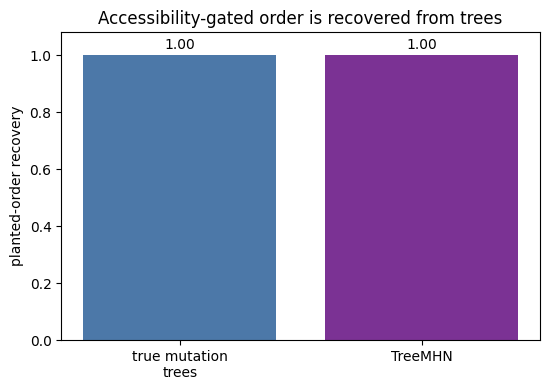

In [6]:
def true_orders():
    return list(order_groups)
def freq_orders():
    freq = Counter()
    for ev in event_sets:
        for e in ev:
            freq[e] += 1
    return [tuple(sorted(ev, key=lambda e: -freq[e])) for ev in event_sets]

print("planted ordering constraints (A before B):", dag)
if dag:
    tm = run_treemhn(trees)
    r_true = ig.score_order(dag, true_orders())
    r_freq = ig.score_order(dag, freq_orders())
    label = "TreeMHN (iscc-treemhn)" if tm is not None else "frequency heuristic"
    print(f"order recovery — true mutation trees: {r_true.get('order_accuracy', float('nan')):.2f} "
          f"(n={r_true.get('n_child', 0)})")
    print(f"order recovery — {label}: {r_freq.get('order_accuracy', float('nan')):.2f}")

    fig, ax = plt.subplots(figsize=(5.6, 4))
    vals = [r_true.get("order_accuracy", 0), r_freq.get("order_accuracy", 0)]
    ax.bar(["true mutation\ntrees", label.split(" (")[0]], vals, color=["#4c78a8", "#7b3294"])
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
    ax.set_ylim(0, 1.08); ax.set_ylabel("planted-order recovery")
    ax.set_title("Accessibility-gated order is recovered from trees")
    plt.tight_layout()
else:
    print("no ordering constraints planted; skipping order recovery")

## What this shows

* iscc plants a **known epistasis network shared across the cohort** — the answer key for MHN /
  TreeMHN / CBN, which real cohorts never have.
* **Recurrence** is strong: shared gene roles make the same events recur across patients (universal at
  a low threshold; the clone *fraction* is where selection actually shows up).
* **MHN** on binary presence recovers interactions only as well as the observable allows — iscc's
  interactions act on clone *fitness*, so recovery hinges on the detection threshold (the honest
  finding, quantified in `validation/validate_epistasis.py`), shown here against the co-occurrence
  floor.
* **TreeMHN** reads event **order** from the mutation trees, and the **accessibility-gated** ordering
  constraint — a constraint on the mutation process itself — is recovered.

**Next / see also:**
[`base_simulation`](base_simulation.ipynb) · [`tree_inference_dna`](tree_inference_dna.ipynb)
(per-patient clonal trees) · [`cohort_shared_programs`](cohort_shared_programs.ipynb) (the RNA side of
the cohort) · `validation/validate_epistasis.py` (the full MHN / TreeMHN benchmark + the observable
finding).